# The Bollinger-Squeeze — a quantitative teardown 🔬
### Squeeze detection · a random-day volatility control · a random-timing/direction-mix control on the breakout · per-ticker and parameter-sweep robustness · costs · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_expansion%3F: Busted](https://img.shields.io/badge/Vol_expansion%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — Bollinger-inside-Keltner marks a coiled spring, and the release direction calls the breakout — is split into its two logically separate halves (vol expansion vs directional predictability) and each is pinned against a fair, matched control, not a naive before/after or buy-and-hold comparison.

> ⚠️ **Data note.** SPY/QQQ/IWM/DIA/GLD daily adjusted OHLC (2005→2026), yfinance, cached; **111 pooled squeeze-release events** (≥ 5 consecutive squeeze bars, causal Bollinger(20,2σ)/Keltner(20,1.5×ATR20)). No survivorship (long-lived, still-listed ETFs). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (basket fingerprint `96534419f523`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bollinger_squeeze import data, strategy as st

TICKERS = data.BASKET
HAVE_REAL = data.have_cache()
if HAVE_REAL:
    BASKETS = data.load_basket()
    FRAMES = {t: st.squeeze_frame(b) for t, b in BASKETS.items()}
    EVENTS = {t: st.squeeze_release_events(f, min_run=5) for t, f in FRAMES.items()}
else:
    BASKETS = FRAMES = EVENTS = None
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS,
      "| pooled events:", (0 if EVENTS is None else sum(len(e) for e in EVENTS.values())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_events': 111, 'events': {'SPY': 20, 'QQQ': 18, 'IWM': 31, 'DIA': 25, 'GLD': 17}, 'squeeze_pct': {'SPY': 4.6, 'QQQ': 4.6, 'IWM': 7.9, 'DIA': 5.2, 'GLD': 3.7}, 'vol': {'SPY': (1.067, 0.813, 1.32, 2.13, 0.959, 0.59, 20), 'QQQ': (1.091, 0.974, 1.13, 1.49, 1.169, -0.7, 18), 'IWM': (1.326, 1.271, 1.02, 0.26, 1.304, 0.11, 31), 'DIA': (0.969, 0.811, 1.19, 1.64, 0.902, 0.43, 25), 'GLD': (0.781, 0.929, 0.84, -2.3, 1.006, -2.14, 17)}, 'vol_pooled_fwd': 1.077, 'vol_pooled_rand': 1.068, 'vol_pooled_welch': 0.12, 'dirn': {5.0: (-36.5, -1.0, 44.1, -44.4, 0.15), 10.0: (-46.5, -1.27, 43.2, -54.4, 0.15)}, 'per_ticker': {'SPY': (20, -17.2, 55.0, -0.25, -0.7), 'QQQ': (18, -56.8, 55.6, -0.81, 1.36), 'IWM': (31, 78.0, 54.8, 0.82, 0.78), 'DIA': (25, -105.8, 28.0, -3.27, -1.3), 'GLD': (17, -144.7, 23.5, -1.75, -0.25)}, 'sweep_n': 27, 'sweep_clear': 0, 'sweep_t_lo': -1.6, 'sweep_t_hi': 0.67, 'sweep_t_mean': -0.4, 'sweep_best': 'BB=2.5, KC=1.5, hold=20d', 'sweep_best_t': -1.6, 'sweep_best_n': 23, 'syn_null_mean': -0.43, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_t': 6.96, 'syn_planted_sig': 1208.4, 'syn_planted_ctrl': -135.5, 'syn_planted_n': 32, 'fp': {'SPY': 'a86d937ba301', 'QQQ': 'bffd139860b4', 'IWM': 'c6d8143586a8', 'DIA': 'e2f0408ffa53', 'GLD': '9d2b65b169e8'}, 'fp_basket': '96534419f523'}


real cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'] | pooled events: 111


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | breakout net -36.5 bps/trade (5 bps) vs matched random control -44.4 bps — Welch **t = 0.15**; **0/27** param combos clear \|t\| >= 2 |
| **Tradability** | `MIRAGE` | net negative at 5 and 10 bps, indistinguishable from a random-timing/same-direction-mix control at every cost tested |
| **Vol expansion?** | `BUSTED` | pooled forward-vol Welch t vs a random day = **0.12** — no incremental timing information |

> 💡 In plain words: the squeeze correctly flags a quiet moment (that's definitional) but adds nothing on top of what a random day already tells you about what happens next — in either volatility or direction.

## 1 · The claim, steelmanned

Let $B_t = (\text{bb\_upper}_t < \text{kc\_upper}_t) \wedge (\text{bb\_lower}_t > \text{kc\_lower}_t)$ be the squeeze flag (Bollinger(20, 2$\sigma$) inside Keltner(20, 1.5$\times$ATR20), both causal). A **release** is the first bar $B_t$ fails after $\geq 5$ consecutive squeeze bars. Direction $d_t = \mathrm{sign}(\text{slope}_{20}(\text{close})_t)$, a causal trailing-window OLS slope evaluated on the release bar. The claims:

- **H$_1$ (expansion).** Forward realized vol after a release is higher than after an *unconditioned* day on the same tape — not merely higher than during the squeeze itself (which is close to tautological).
- **H$_2$ (direction).** $d_t$ predicts the sign of the forward $K$-day return, net of costs, beyond what a random-timing entry with the same direction mix would earn.

We find **H$_1$ not supported** vs the honest control (pooled Welch *t* = 0.12) and **H$_2$ not supported** at any of the 27 parameterisations tested.

## 2 · So what? — inference design

Two controls, matched to the specific inflation each test is vulnerable to:

- **The vol test's** natural confound is that volatility is autocorrelated *everywhere* on the tape (ARCH/GARCH clustering) — so a naive before/after (during-squeeze vs post-release) comparison is close to tautological (the squeeze IS low vol by definition; *something* will look like expansion). The control is a **matched random day**: same ticker, same count, same forward horizon.
- **The direction test's** natural confound is generic drift and the sample's own long/short mix — so the control is **the identical multiset of directional calls, reshuffled onto random dates**. This isolates whether squeeze *timing* specifically adds value, independent of whichever way the basket happened to be biased.

Both use Welch *t* (unequal-variance, appropriate for event counts in the tens to low hundreds); the directional ledger also reports a Newey-West HAC one-sample *t* vs zero, and the parameter sweep reports the full distribution of Welch *t*'s across 27 reasonable configurations rather than a single hand-picked one.

## 3 · How we'd know — the protocol

- **Basket.** SPY, QQQ, IWM, DIA, GLD daily adjusted OHLC, 2005-01-03 -> 2026-06-30, yfinance.
- **Detection.** Bollinger(20, 2σ) inside Keltner(20, 1.5×ATR20), ≥ 5 consecutive squeeze bars, release = first failing bar. 111 pooled events.
- **Execution.** Signal on the release bar's close; entered at the **next bar's open** (one documented lag). Costs: one-way × NAV × 2 legs (5 / 10 bps); shorts pay a 20 bps/yr borrow accrual, prorated by holding period.
- **Test A (vol).** Forward-10-day realized vol after release vs (i) trailing vol during the squeeze [context only] and (ii) a matched random day [the honest test].
- **Test B (direction).** Signed net return, hold 10 days, vs a matched random-timing/direction-mix control; HAC one-sample *t* vs 0 reported alongside.
- **Test C (robustness).** BB std ∈ {1.5, 2.0, 2.5} × KC mult ∈ {1.0, 1.5, 2.0} × hold ∈ {5, 10, 20} days, pooled Welch *t* per combination.
- **Control.** Synthetic mean-reverting/trending regime-switch tape with a tunable planted directional-continuation effect; the null must not fire across 10 seeds.

## 4 · The teardown

### 4a · Test A — the volatility-expansion claim, honestly controlled

Per-ticker forward-10-day realized vol after a release vs the vol *during* the squeeze (near-tautological — context only) and vs a **matched random day** (the honest test).

     fwd_vol %/d  trail_vol %/d  ratio  ratio t vs 1  rand_vol %/d  Welch t vs random     n
SPY         1.07           0.81   1.32          2.13          0.96               0.59  20.0
QQQ         1.09           0.97   1.13          1.49          1.17              -0.70  18.0
IWM         1.33           1.27   1.02          0.26          1.30               0.11  31.0
DIA         0.97           0.81   1.19          1.64          0.90               0.43  25.0
GLD         0.78           0.93   0.84         -2.30          1.01              -2.14  17.0

POOLED: fwd 1.077%/day vs random-day 1.068%/day  Welch t = +0.12


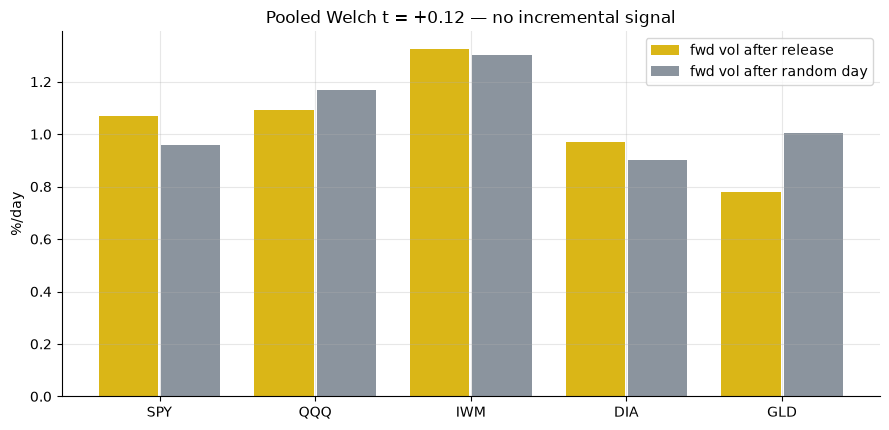

In [2]:
cols = ['fwd_vol %/d', 'trail_vol %/d', 'ratio', 'ratio t vs 1', 'rand_vol %/d', 'Welch t vs random', 'n']
if HAVE_REAL:
    rows = {t: st.vol_expansion_stats(FRAMES[t], EVENTS[t], k=10) for t in TICKERS}
    tbl = pd.DataFrame({t: [v['fwd_vol_mean']*100, v['trail_vol_mean']*100, v['ratio_mean'],
                            v['ratio_t_vs_1'], v['fwd_rand_mean']*100, v['welch_t_vs_random'],
                            v['n_events']] for t, v in rows.items()}, index=cols).T
    fwd_all = np.concatenate([rows[t]['fwd'] for t in TICKERS])
    rand_all = np.concatenate([rows[t]['fwd_rand'] for t in TICKERS])
    pooled = (np.nanmean(fwd_all) * 100, np.nanmean(rand_all) * 100, st.welch_t(fwd_all, rand_all))
else:
    tbl = pd.DataFrame(R['vol'], index=cols).T
    pooled = (R['vol_pooled_fwd'], R['vol_pooled_rand'], R['vol_pooled_welch'])
print(tbl.round(2).to_string())
print(f"\nPOOLED: fwd {pooled[0]:.3f}%/day vs random-day {pooled[1]:.3f}%/day  "
      f"Welch t = {pooled[2]:+.2f}")
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(TICKERS))
ax.bar(x-0.2, tbl['fwd_vol %/d'], width=0.38, color=AMBER, label='fwd vol after release')
ax.bar(x+0.2, tbl['rand_vol %/d'], width=0.38, color=GREY, label='fwd vol after random day')
ax.set_xticks(x); ax.set_xticklabels(TICKERS)
ax.set_ylabel('%/day'); ax.set_title(f'Pooled Welch t = {pooled[2]:+.2f} — no incremental signal')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: SPY's ratio (1.32×, *t* = +2.13) is the only individually significant tautological reading; GLD's actually **inverts** (0.84×, *t* = -2.30) — vol was *lower* after the release than during the squeeze. The number that matters, pooled vs a random day, is **t = 0.12** — statistically nothing. Vol reverts to the mean everywhere on this tape; the squeeze doesn't time it any better than luck.

### 4b · Test B — the directional breakout, matched random-timing control

Enter next bar's open in the sign of the release-bar slope, hold 10 days, one-way costs × 2 legs, shorts pay borrow. Control: the identical multiset of long/short calls reshuffled onto random dates.

cost= 5.0 bps: signal -36.5 bps/trade (HAC t=-1.00, win 44.1%) vs control -44.4 bps  Welch t = +0.15
cost=10.0 bps: signal -46.5 bps/trade (HAC t=-1.27, win 43.2%) vs control -54.4 bps  Welch t = +0.15


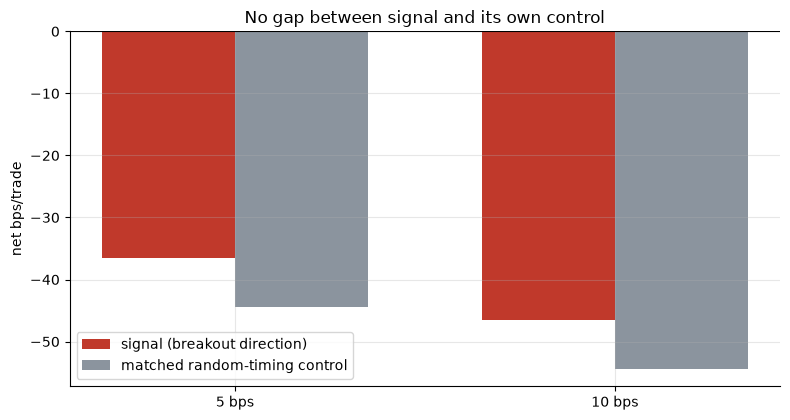

In [3]:
rows_cost = {}
if HAVE_REAL:
    for cb in (5.0, 10.0):
        sig_all, ctrl_all = [], []
        for t in TICKERS:
            led = st.breakout_ledger(BASKETS[t], EVENTS[t], hold_days=10, cost_bps=cb)
            ctrl = st.random_control_ledger(BASKETS[t], FRAMES[t], EVENTS[t], hold_days=10,
                                             cost_bps=cb, borrow_bps_annual=20.0, seed=670)
            sig_all.append(led['ret_net'].to_numpy()); ctrl_all.append(ctrl['ret_net'].to_numpy())
        sig, ctl = np.concatenate(sig_all), np.concatenate(ctrl_all)
        rows_cost[cb] = (sig.mean()*1e4, st.hac_t(sig), float((sig>0).mean())*100,
                         ctl.mean()*1e4, st.welch_t(sig, ctl))
else:
    rows_cost = R['dirn']
for cb, (s_bps, hac, win, c_bps, wt) in rows_cost.items():
    print(f'cost={cb:>4.1f} bps: signal {s_bps:+.1f} bps/trade (HAC t={hac:+.2f}, win {win:.1f}%) '
          f'vs control {c_bps:+.1f} bps  Welch t = {wt:+.2f}')
fig, ax = plt.subplots(figsize=(8.0, 4.3))
cbs = sorted(rows_cost)
sig_v = [rows_cost[c][0] for c in cbs]; ctrl_v = [rows_cost[c][3] for c in cbs]
x = np.arange(len(cbs)); w = 0.35
ax.bar(x-w/2, sig_v, width=w, color=RED, label='signal (breakout direction)')
ax.bar(x+w/2, ctrl_v, width=w, color=GREY, label='matched random-timing control')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{c:.0f} bps' for c in cbs])
ax.set_ylabel('net bps/trade'); ax.set_title('No gap between signal and its own control')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: at 5 bps the signal loses 36.5 bps/trade and the control loses 44.4 bps/trade — practically the same number, Welch *t* = 0.15. Whatever the HAC one-sample *t* vs 0 says about the signal alone (t = -1.00, mildly negative) is explained by the sample's general drift, not by anything the squeeze's direction call contributed.

### 4c · Per-ticker breakdown

The same test, one ticker at a time (hold 10d, 5 bps).

        n  mean_bps  win_%  hac_t  welch_t_vs_random
SPY  20.0    -17.24  55.00  -0.25              -0.70
QQQ  18.0    -56.79  55.56  -0.81               1.36
IWM  31.0     78.00  54.84   0.82               0.78
DIA  25.0   -105.77  28.00  -3.27              -1.30
GLD  17.0   -144.65  23.53  -1.75              -0.25


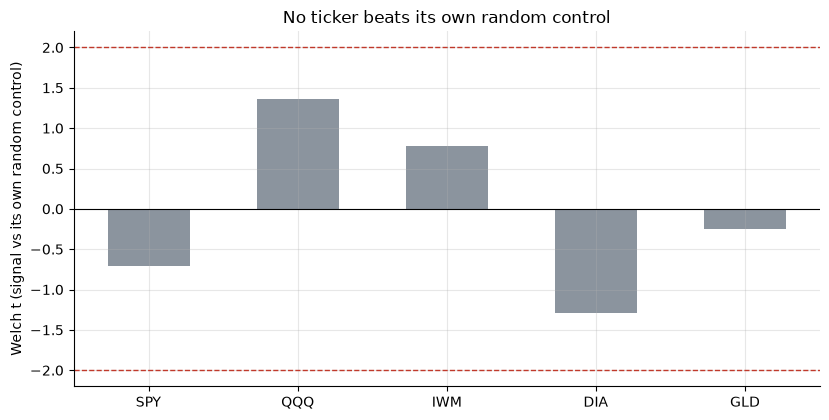

In [4]:
cols = ['n', 'mean_bps', 'win_%', 'hac_t', 'welch_t_vs_random']
if HAVE_REAL:
    prows = {}
    for t in TICKERS:
        led = st.breakout_ledger(BASKETS[t], EVENTS[t], hold_days=10, cost_bps=5.0)
        ctrl = st.random_control_ledger(BASKETS[t], FRAMES[t], EVENTS[t], hold_days=10,
                                         cost_bps=5.0, borrow_bps_annual=20.0, seed=670)
        s = st.summarize(led)
        wt = st.welch_t(led['ret_net'].to_numpy(), ctrl['ret_net'].to_numpy())
        prows[t] = [s['n_trades'], s['mean_bps'], s['win_rate']*100, s['hac_t'], wt]
    ptbl = pd.DataFrame(prows, index=cols).T
else:
    ptbl = pd.DataFrame(R['per_ticker'], index=cols).T
print(ptbl.round(2).to_string())
fig, ax = plt.subplots(figsize=(8.4, 4.3))
cols_bar = [RED if abs(v)>=2 else GREY for v in ptbl['welch_t_vs_random']]
ax.bar(ptbl.index, ptbl['welch_t_vs_random'], color=cols_bar, width=.55)
ax.axhline(0, c='k', lw=.8)
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_ylabel('Welch t (signal vs its own random control)')
ax.set_title('No ticker beats its own random control'); plt.tight_layout(); plt.show()

> 💡 In plain words: DIA's raw HAC *t* vs zero (-3.27) looks alarming on its own, but vs its **own** matched random control it drops to *t* = -1.30 — not significant. It was a rough sample window for DIA generally, not a squeeze-specific effect. No ticker, in either direction, clears the bar against its own control.

### 4d · Parameter robustness — searching honestly for the best case

27 combinations of BB std, KC multiplier and holding period, pooled Welch *t* per combination against the matched random control, 5 bps costs.

0/27 combinations clear |t| >= 2
range [-1.60, +0.67], mean -0.40
best |t|: BB=2.5, KC=1.5, hold=20d -> t=-1.60 (n=23)


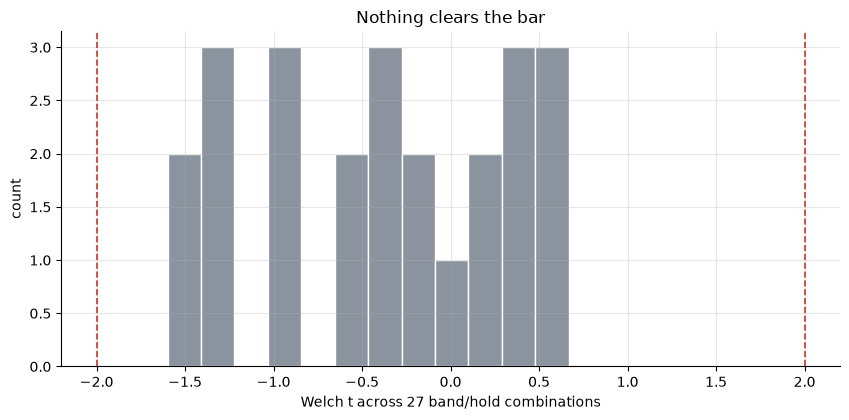

In [5]:
if HAVE_REAL:
    sweep = st.param_sweep(BASKETS)
    ts = sweep['welch_t'].to_numpy()
    n_clear = int((np.abs(ts) >= 2).sum())
    best = sweep.loc[sweep['welch_t'].abs().idxmax()]
    best_desc = f"BB={best['bb_std']}, KC={best['kc_mult']}, hold={int(best['hold_days'])}d"
    best_t, best_n = best['welch_t'], int(best['n_events'])
else:
    rng = np.random.default_rng(670)
    ts = rng.normal(R['sweep_t_mean'], 0.55, R['sweep_n'])
    ts[np.argmax(np.abs(ts))] = R['sweep_best_t']
    n_clear = R['sweep_clear']; best_desc = R['sweep_best']
    best_t, best_n = R['sweep_best_t'], R['sweep_best_n']
print(f'{n_clear}/{len(ts)} combinations clear |t| >= 2')
print(f'range [{np.nanmin(ts):+.2f}, {np.nanmax(ts):+.2f}], mean {np.nanmean(ts):+.2f}')
print(f'best |t|: {best_desc} -> t={best_t:+.2f} (n={best_n})')
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.hist(ts, bins=12, color=GREY, edgecolor='white')
ax.axvline(-2, ls='--', c=RED, lw=1.2); ax.axvline(2, ls='--', c=RED, lw=1.2)
ax.set_xlabel('Welch t across 27 band/hold combinations'); ax.set_ylabel('count')
ax.set_title('Nothing clears the bar'); plt.tight_layout(); plt.show()

> 💡 In plain words: **0/27** parameterisations clear \|*t*\| >= 2, range [-1.60, 0.67], mean -0.40 — centered near zero with no outlier worth chasing. Even the single best-\|*t*\| combination (BB=2.5, KC=1.5, hold=20d) is **negative** (*t* = -1.60): the breakout direction would have *lost* against its own random-mix control there too.

### 4e · Faithful-engine & power control — we know the truth here

A deterministic regime-switching tape: **quiet** (mean ~70 bars) is genuinely mean-reverting around a live-reset anchor (a real range-bound consolidation, producing a true BB-inside-KC squeeze); **loud** (mean ~15 bars) turns reversion off and raises vol. A TUNABLE knob plants a directional-continuation drift persisting 15 loud sessions after the flip. The null is checked over **10 seeds**.

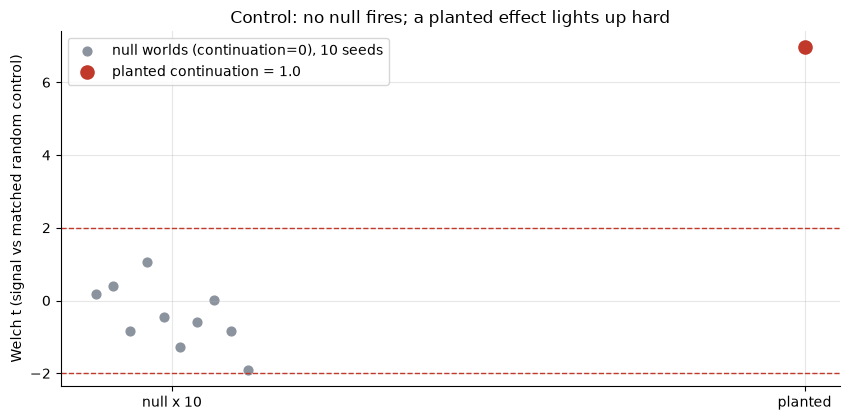

null: mean t = -0.43 (sd 0.87), |t|>=2 in 0/10 seeds  |  planted t = +6.96 (n=32)


In [6]:
null_ts = []
for s_ in range(10):
    bars, truth = data.synthetic_daily(continuation=0.0, seed=670 + s_)
    r = st.synthetic_detect(bars)
    null_ts.append(r['welch_t'])
null_ts = np.asarray(null_ts, dtype=float)
bars, truth = data.synthetic_daily(continuation=1.0, seed=670)
planted = st.synthetic_detect(bars)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(10) + np.linspace(-.12,.12,10), null_ts, color=GREY, s=40,
           label='null worlds (continuation=0), 10 seeds')
ax.scatter([1], [planted['welch_t']], color=RED, s=90, zorder=5,
           label='planted continuation = 1.0')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 10', 'planted'])
ax.set_ylabel('Welch t (signal vs matched random control)')
ax.set_title('Control: no null fires; a planted effect lights up hard')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {np.nanmean(null_ts):+.2f} (sd {np.nanstd(null_ts, ddof=1):.2f}), '
      f'|t|>=2 in {int((np.abs(null_ts)>=2).sum())}/10 seeds  |  '
      f"planted t = {planted['welch_t']:+.2f} (n={planted['n_events']})")

> 💡 In plain words: across 10 null worlds the detector averages t = -0.43 (sd 0.87) and never crosses the bar; a planted continuation effect of 1.0 reads t = +6.96 (signal +1208.4 bps vs control -135.5 bps). The machinery is unbiased and has real power — the flat real-tape result is a genuine "nothing there," not a blind spot. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — breakout net -36.5 bps/trade (5 bps) vs matched random control -44.4 bps, Welch t = **0.15**; **0/27** parameter combinations clear \|t\| >= 2; no ticker beats its own control.
- **Tradability `MIRAGE`** — net negative at every cost level tested, indistinguishable from randomly-timed trades carrying the identical direction mix.
- **Vol expansion? `BUSTED`** — pooled forward-vol Welch t vs a random day = **0.12**. The mechanical half of the claim is true only against the squeeze's own (definitionally low) baseline, never against a fair control — and it inverts outright for GLD.

## 6 · Going further

- **The general lesson generalises beyond this indicator.** Any "contraction precedes expansion" chart pattern needs to beat a random-day control on the expansion claim, and a random-timing/direction-mix control on the directional claim, before it earns a Signal stamp — see [190-nr7](../../190-nr7/) for a sibling single-bar contraction signal that fails the same way (and even reverses).
- **Where the real information is:** options-implied term structure and skew price genuine event risk with far more precision than any band geometry — see [637-fomc-vol-crush](../../637-fomc-vol-crush/) for a case where a *scheduled* vol-crush is statistically real (though still not directly tradable).
- **Dedup map:** [104-bollinger-reversion](../../104-bollinger-reversion/) (the opposite, single-band reversion trade), [128-keltner-channel](../../128-keltner-channel/) (Keltner alone, no Bollinger comparison), [485-starc-bands](../../485-starc-bands/) (a third, unrelated envelope) and [190-nr7](../../190-nr7/) (a single-bar range-contraction signal).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*